In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "segmentation-models-pytorch", "albumentations"], check=True)
 
import os, glob, json, random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import GroupShuffleSplit
import scipy.io as sio
import matplotlib.pyplot as plt
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.6 MB/s eta 0:00:00


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT = "/kaggle/working"
IMG = 256
BATCH = 16
EPOCHS = 30          
LR = 1e-4
PATIENCE = 7        
FP_PX = 50        
print("device:", DEVICE)

device: cuda


In [3]:
import os

# see exactly what's under /kaggle/input
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.count(os.sep) - "/kaggle/input".count(os.sep)
    if depth <= 2:
        print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mateuszbuda
/kaggle/input/datasets/ashkhagan


In [4]:
#  LGG file list 
LGG_BASE = "/kaggle/input/datasets/mateuszbuda"

images = sorted(p for p in glob.glob(f"{LGG_BASE}/**/*.tif", recursive=True) if "_mask" not in p)
rows = []
for ip in images:
    mp = ip.replace(".tif", "_mask.tif")
    if os.path.exists(mp):
        rows.append((ip, mp, os.path.basename(os.path.dirname(ip))))   # patient = parent folder name

df = pd.DataFrame(rows, columns=["img", "mask", "patient"])
assert len(df) > 0, f"No image/mask pairs found under {LGG_BASE} — check the debug print"
print(len(df), "slices from", df.patient.nunique(), "patients")

7858 slices from 110 patients


In [5]:
#  split by PATIENT, not by slice 

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
tr, tmp = next(gss.split(df, groups=df.patient))
train_df, tmp_df = df.iloc[tr].reset_index(drop=True), df.iloc[tmp].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
va, te = next(gss2.split(tmp_df, groups=tmp_df.patient))
val_df, test_df = tmp_df.iloc[va].reset_index(drop=True), tmp_df.iloc[te].reset_index(drop=True)

print(f"train {len(train_df)}  val {len(val_df)}  test {len(test_df)}")
assert not (set(train_df.patient) & set(val_df.patient) & set(test_df.patient))
assert not (set(train_df.patient) & set(test_df.patient)), "patient leak between train and test"


train 5500  val 1146  test 1212


In [6]:
# data pipeline

train_tf = A.Compose([
    A.Resize(IMG, IMG),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Resize(IMG, IMG), A.Normalize(), ToTensorV2()])


class SegDS(Dataset):
    def __init__(self, frame, tf):
        self.frame, self.tf = frame, tf

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        r = self.frame.iloc[i]
        img = cv2.cvtColor(cv2.imread(r["img"]), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(r["mask"], 0) > 0).astype("float32")
        out = self.tf(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0)


train_dl = DataLoader(SegDS(train_df, train_tf), BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(SegDS(val_df,   eval_tf),  BATCH, shuffle=False, num_workers=2, pin_memory=True)


In [7]:
#   model, loss, metric 
model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)

bce = nn.BCEWithLogitsLoss()
dsc = smp.losses.DiceLoss(mode="binary")

def loss_fn(logits, y):
  
    return 0.5 * bce(logits, y) + 0.5 * dsc(logits, y)

def batch_dice(logits, y, eps=1e-7):
    p = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * y).sum((1, 2, 3))
    denom = p.sum((1, 2, 3)) + y.sum((1, 2, 3))
    return ((2 * inter + eps) / (denom + eps)).mean().item()

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))



config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

/tmp/ipykernel_23/1081189391.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


In [8]:
#     train 
@torch.no_grad()
def val_dice():
    model.eval()
    s = 0.0
    for x, y in val_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        s += batch_dice(model(x), y)
    return s / len(val_dl)

best, bad = 0.0, 0
for ep in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_dl, desc=f"epoch {ep}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(x)
            l = loss_fn(logits, y)
        scaler.scale(l).backward()
        scaler.step(opt)
        scaler.update()
        running += l.item()

    vd = val_dice()
    sched.step(vd)
    print(f"  loss {running/len(train_dl):.4f}   val dice {vd:.4f}   lr {opt.param_groups[0]['lr']:.1e}")

    if vd > best:
        best, bad = vd, 0
        torch.save(model.state_dict(), f"{OUT}/best.pt")
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"no improvement in {PATIENCE} epochs, stopping")
            break

print("best val dice:", round(best, 4))
model.load_state_dict(torch.load(f"{OUT}/best.pt"))


epoch 1/30:   0%|          | 0/344 [00:00<?, ?it/s]/tmp/ipykernel_23/3732592403.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
epoch 1/30: 100%|██████████| 344/344 [02:17<00:00,  2.51it/s]


  loss 0.6374   val dice 0.2124   lr 1.0e-04


epoch 2/30: 100%|██████████| 344/344 [00:40<00:00,  8.55it/s]


  loss 0.4426   val dice 0.8037   lr 1.0e-04


epoch 3/30: 100%|██████████| 344/344 [00:40<00:00,  8.40it/s]


...

epoch 29/30: 100%|██████████| 344/344 [00:43<00:00,  7.99it/s]


  loss 0.0530   val dice 0.9110   lr 2.5e-05


epoch 30/30: 100%|██████████| 344/344 [00:43<00:00,  7.99it/s]


  loss 0.0526   val dice 0.9056   lr 2.5e-05
best val dice: 0.911


<All keys matched successfully>

In [9]:
#     per-image metrics (shared by both datasets) 
def sample_stats(logit, y, thr=0.5, eps=1e-7):
    p = (torch.sigmoid(logit) > thr).float()
    y = (y > 0.5).float()
    tp = (p * y).sum().item()
    fp = (p * (1 - y)).sum().item()
    fn = ((1 - p) * y).sum().item()
    tn = ((1 - p) * (1 - y)).sum().item()
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    return dice, iou, tp, fp, fn, tn, p.sum().item()


@torch.no_grad()
def metrics_lgg(frame):
    model.eval()
    recs = []
    for _, r in tqdm(frame.iterrows(), total=len(frame), desc="lgg eval"):
        img = cv2.cvtColor(cv2.imread(r["img"]), cv2.COLOR_BGR2RGB)
        m = (cv2.imread(r["mask"], 0) > 0).astype("float32")
        t = eval_tf(image=img, mask=m)
        x = t["image"].unsqueeze(0).to(DEVICE)
        y = (t["mask"] > 0.5).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        d, iou, tp, fp, fn, tn, px = sample_stats(model(x), y)
        recs.append(dict(img=r["img"], mask=r["mask"], patient=r["patient"],
                         has_tumor=bool(m.sum() > 0), dice=d, iou=iou,
                         tp=tp, fp=fp, fn=fn, tn=tn, pred_px=px))
    return pd.DataFrame(recs)


def summarize(m, name):
    tp, fp, fn, tn = m.tp.sum(), m.fp.sum(), m.fn.sum(), m.tn.sum()
    pos = m[m.has_tumor]
    neg = m[~m.has_tumor]
    per_pat = m.groupby("patient").dice.mean() if "patient" in m and m.patient.nunique() > 1 else None
    out = {
        "n_images": int(len(m)),
        "dice_all": round(float(m.dice.mean()), 4),
        "iou_all": round(float(m.iou.mean()), 4),
        "dice_tumor_only": round(float(pos.dice.mean()), 4) if len(pos) else None,
        "iou_tumor_only": round(float(pos.iou.mean()), 4) if len(pos) else None,
        "sensitivity": round(float(tp / (tp + fn + 1e-7)), 4),
        "specificity": round(float(tn / (tn + fp + 1e-7)), 4),
        "fp_slice_rate": round(float((neg.pred_px > FP_PX).mean()), 4) if len(neg) else None,
    }
    if per_pat is not None:
        out["dice_per_patient_mean"] = round(float(per_pat.mean()), 4)
        out["dice_per_patient_std"] = round(float(per_pat.std()), 4)
        out["n_patients"] = int(per_pat.shape[0])
    print(f"\n[{name}]")
    for k, v in out.items():
        print(f"  {k:24s}: {v}")
    return out

In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/ashkhagan"):
    depth = root.count(os.sep) - "/kaggle/input/datasets/ashkhagan".count(os.sep)
    if depth <= 3:
        print(root, "->", files[:3] if files else "")

/kaggle/input/datasets/ashkhagan -> 
/kaggle/input/datasets/ashkhagan/figshare-brain-tumor-dataset -> 
/kaggle/input/datasets/ashkhagan/figshare-brain-tumor-dataset/dataset -> ['README.txt', 'cvind.mat']
/kaggle/input/datasets/ashkhagan/figshare-brain-tumor-dataset/dataset/data -> ['2912.mat', '2011.mat', '3027.mat']


In [11]:
#    score #1: LGG test set (same source) 
lgg_m = metrics_lgg(test_df)
lgg_m.to_csv(f"{OUT}/lgg_per_image.csv", index=False)
lgg_summary = summarize(lgg_m, "LGG test (same source)")


FIG_ROOT = "/kaggle/input/datasets/ashkhagan/figshare-brain-tumor-dataset/dataset/data"

def read_mat(path):
    try:
        d = sio.loadmat(path)["cjdata"]
        img, mask = d["image"][0, 0], d["tumorMask"][0, 0]
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            img = np.array(f["cjdata"]["image"]).T
            mask = np.array(f["cjdata"]["tumorMask"]).T
    return np.asarray(img, dtype="float32"), (np.asarray(mask) > 0).astype("float32")

fig_paths = sorted(p for p in glob.glob(f"{FIG_ROOT}/**/*.mat", recursive=True)
                    if os.path.basename(p) != "cvind.mat")
print(len(fig_paths), "figshare files found")

_img0, _msk0 = read_mat(fig_paths[0])
print("sample shapes:", _img0.shape, _msk0.shape)

@torch.no_grad()
def metrics_figshare(paths):
    model.eval()
    recs, skipped = [], 0
    for p in tqdm(paths, desc="figshare eval"):
        try:
            img, mask = read_mat(p)
        except Exception:
            skipped += 1
            continue
        img = (img / (img.max() + 1e-7) * 255).astype("uint8")   # uint16 -> 0..255
        img = np.stack([img] * 3, -1)                            # gray -> 3 channels
        t = eval_tf(image=img, mask=mask)
        x = t["image"].unsqueeze(0).to(DEVICE)
        y = (t["mask"] > 0.5).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        d, iou, tp, fp, fn, tn, px = sample_stats(model(x), y)
        recs.append(dict(path=p, has_tumor=bool(mask.sum() > 0), dice=d, iou=iou,
                         tp=tp, fp=fp, fn=fn, tn=tn, pred_px=px))
    if skipped:
        print(f"skipped {skipped} unreadable files")
    return pd.DataFrame(recs)

fig_m = metrics_figshare(fig_paths)
fig_m.to_csv(f"{OUT}/figshare_per_image.csv", index=False)
fig_summary = summarize(fig_m, "Figshare (new source)")



lgg eval: 100%|██████████| 1212/1212 [00:46<00:00, 26.29it/s]



[LGG test (same source)]
  n_images                : 1212
  dice_all                : 0.8882
  iou_all                 : 0.8619
  dice_tumor_only         : 0.7459
  iou_tumor_only          : 0.6792
  sensitivity             : 0.8073
  specificity             : 0.9986
  fp_slice_rate           : 0.0163
  dice_per_patient_mean   : 0.878
  dice_per_patient_std    : 0.0918
  n_patients              : 17
3064 figshare files found
sample shapes: (512, 512) (512, 512)


figshare eval: 100%|██████████| 3064/3064 [02:23<00:00, 21.36it/s]



[Figshare (new source)]
  n_images                : 3064
  dice_all                : 0.2209
  iou_all                 : 0.1897
  dice_tumor_only         : 0.2209
  iou_tumor_only          : 0.1897
  sensitivity             : 0.2161
  specificity             : 0.9999
  fp_slice_rate           : None



=== generalization test ===
LGG dice      : 0.8882
Figshare dice : 0.2209
gap           : 0.6673


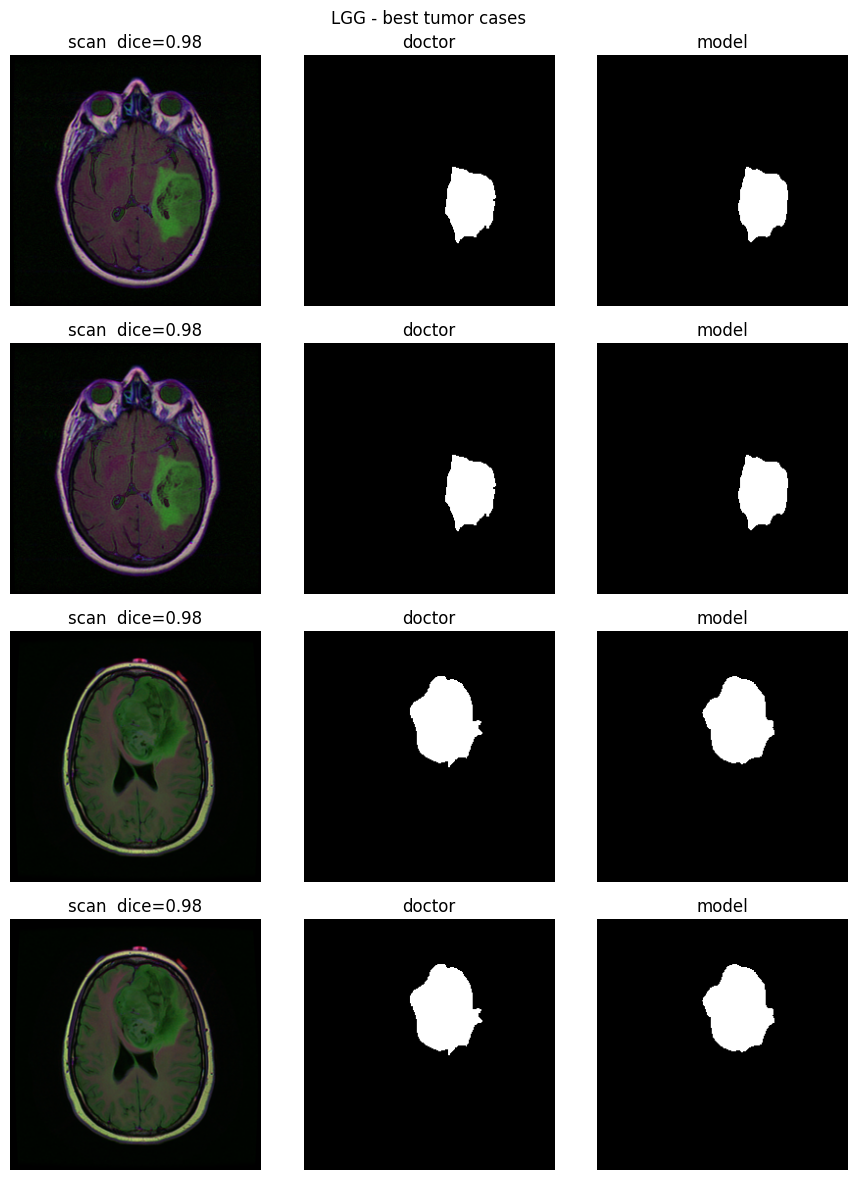

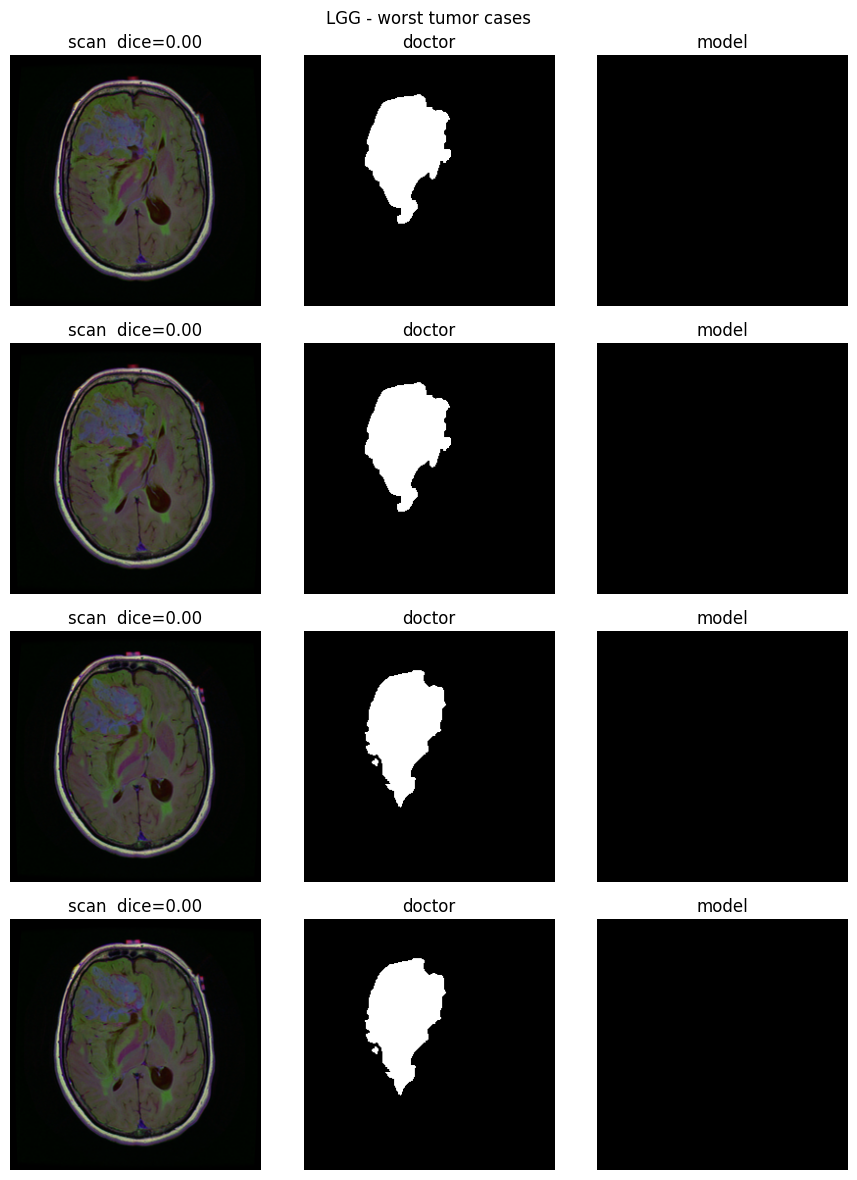

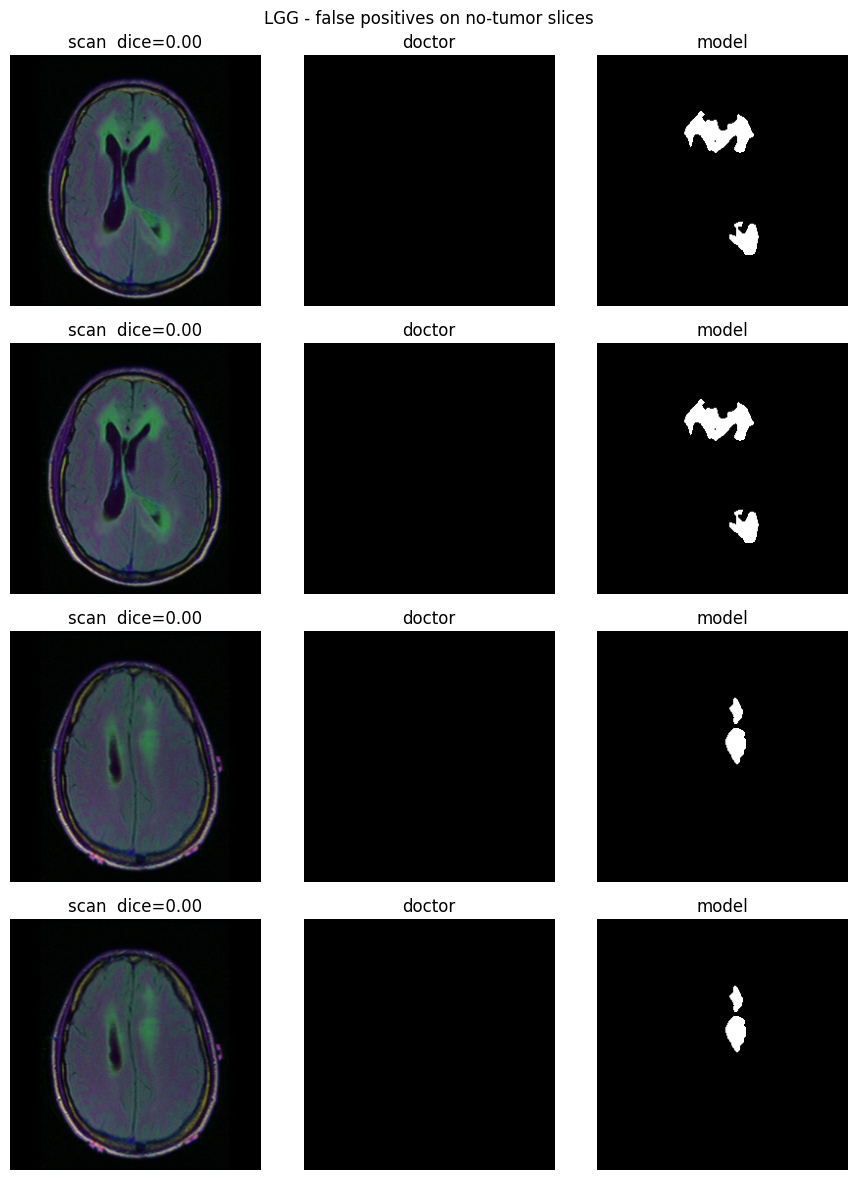


saved to /kaggle/working:
  results.json, lgg_per_image.csv, figshare_per_image.csv
  gallery_best.png, gallery_worst.png, gallery_false_pos.png, best.pt


In [12]:
# ==== the result ====
gap = round(lgg_summary["dice_all"] - fig_summary["dice_all"], 4)
results = {"lgg": lgg_summary, "figshare": fig_summary, "dice_gap": gap,
           "best_val_dice": round(best, 4)}
with open(f"{OUT}/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n=== generalization test ===")
print(f"LGG dice      : {lgg_summary['dice_all']}")
print(f"Figshare dice : {fig_summary['dice_all']}")
print(f"gap           : {gap}")



# ==== prediction galleries 
@torch.no_grad()
def show_rows(rows, title, savepath):
    n = len(rows)
    if n == 0:
        print(f"nothing to show for: {title}")
        return
    model.eval()
    fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        ax = ax.reshape(1, -1)
    for i, (_, r) in enumerate(rows.iterrows()):
        img = cv2.cvtColor(cv2.imread(r["img"]), cv2.COLOR_BGR2RGB)
        gt = (cv2.imread(r["mask"], 0) > 0).astype("float32")
        x = eval_tf(image=img, mask=gt)["image"].unsqueeze(0).to(DEVICE)
        pr = (torch.sigmoid(model(x))[0, 0].cpu().numpy() > 0.5)
        ax[i, 0].imshow(img); ax[i, 0].set_title(f"scan  dice={r['dice']:.2f}")
        ax[i, 1].imshow(gt, cmap="gray"); ax[i, 1].set_title("doctor")
        ax[i, 2].imshow(pr, cmap="gray"); ax[i, 2].set_title("model")
        for a in ax[i]:
            a.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(savepath, dpi=110, bbox_inches="tight")
    plt.show()

# good cases
best_pos = lgg_m[lgg_m.has_tumor].nlargest(4, "dice")
show_rows(best_pos, "LGG - best tumor cases", f"{OUT}/gallery_best.png")

# worst cases (where it struggles - this is the interesting part)
worst_pos = lgg_m[lgg_m.has_tumor].nsmallest(4, "dice")
show_rows(worst_pos, "LGG - worst tumor cases", f"{OUT}/gallery_worst.png")

# false positives: healthy slices where the model invented a tumor
false_pos = lgg_m[(~lgg_m.has_tumor) & (lgg_m.pred_px > FP_PX)].nlargest(4, "pred_px")
show_rows(false_pos, "LGG - false positives on no-tumor slices", f"{OUT}/gallery_false_pos.png")

print("\nsaved to /kaggle/working:")
print("  results.json, lgg_per_image.csv, figshare_per_image.csv")
print("  gallery_best.png, gallery_worst.png, gallery_false_pos.png, best.pt")

                mean  count
tumor_type                 
glioma      0.078243   1426
meningioma  0.593880    708
pituitary   0.155814    930


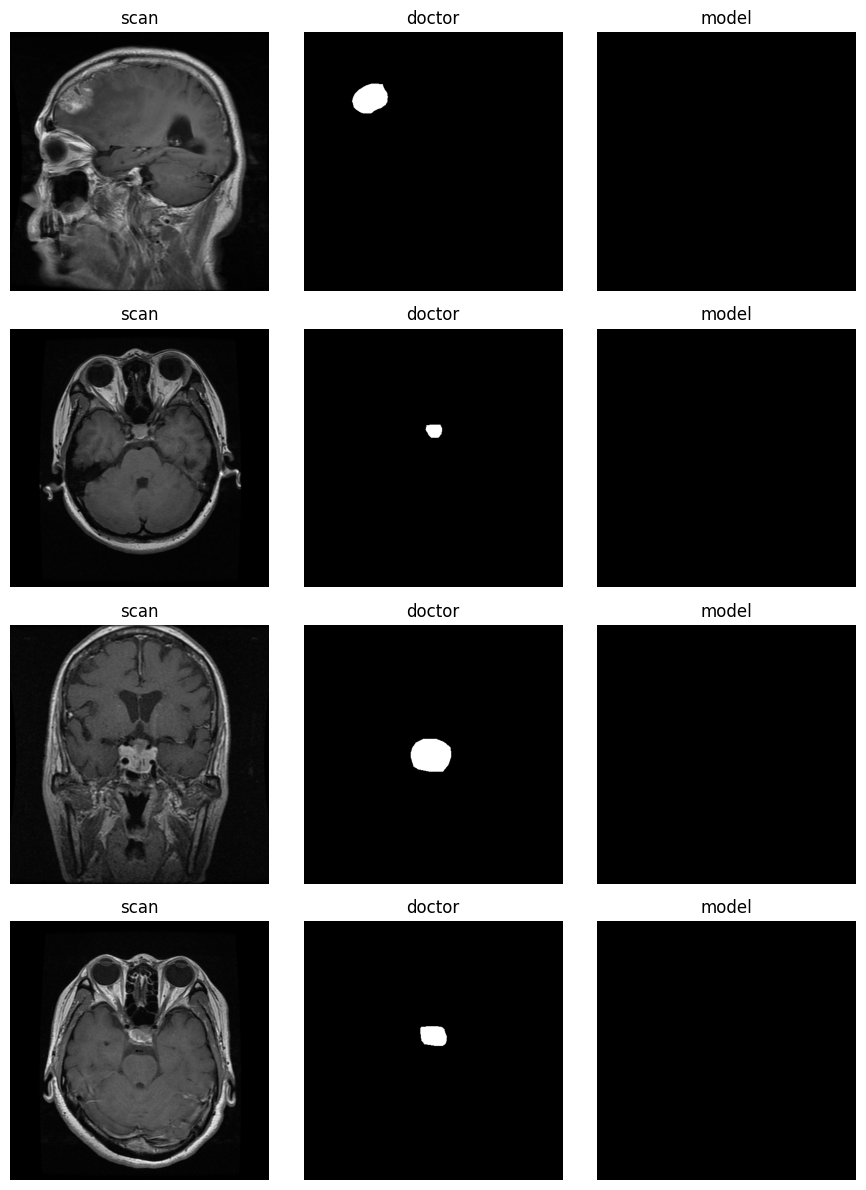

In [13]:
# break down figshare score by tumor type, and save a quick visual check
def read_mat_full(path):
    try:
        d = sio.loadmat(path)["cjdata"]
        label = int(d["label"][0, 0][0, 0])
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            label = int(np.array(f["cjdata"]["label"])[0, 0])
    return label

label_map = {1: "meningioma", 2: "glioma", 3: "pituitary"}

labels = []
for p in fig_m["path"]:
    try:
        labels.append(label_map[read_mat_full(p)])
    except Exception:
        labels.append("unknown")
fig_m["tumor_type"] = labels

print(fig_m.groupby("tumor_type")["dice"].agg(["mean", "count"]))

# visual sanity check: pick a few figshare cases and see the actual prediction
@torch.no_grad()
def show_figshare(paths, n=4):
    model.eval()
    picks = random.sample(paths, n)
    fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n))
    for i, p in enumerate(picks):
        img, mask = read_mat(p)
        img8 = (img / (img.max() + 1e-7) * 255).astype("uint8")
        img3 = np.stack([img8] * 3, -1)
        t = eval_tf(image=img3, mask=mask)
        x = t["image"].unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(model(x))[0, 0].cpu().numpy() > 0.5)
        ax[i, 0].imshow(img8, cmap="gray"); ax[i, 0].set_title("scan")
        ax[i, 1].imshow(mask, cmap="gray"); ax[i, 1].set_title("doctor")
        ax[i, 2].imshow(pred, cmap="gray"); ax[i, 2].set_title("model")
        for a in ax[i]:
            a.axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUT}/gallery_figshare.png", dpi=110, bbox_inches="tight")
    plt.show()

show_figshare(fig_paths, n=4)

                  gt_px      dice  count
tumor_type                              
glioma      5778.560309  0.078243   1426
meningioma  4654.682203  0.593880    708
pituitary   2163.870968  0.155814    930


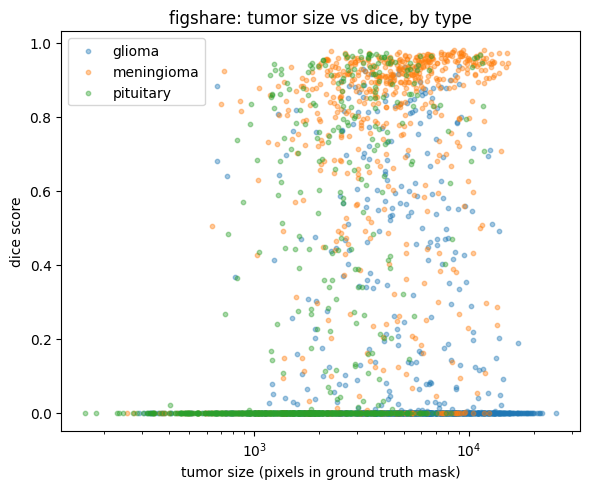

In [14]:
# ground truth tumor size (pixel count) per file, then compare with dice by type
def mask_pixel_count(path):
    _, mask = read_mat(path)
    return int(mask.sum())

fig_m["gt_px"] = [mask_pixel_count(p) for p in fig_m["path"]]

size_dice = fig_m.groupby("tumor_type")[["gt_px", "dice"]].mean()
size_dice["count"] = fig_m.groupby("tumor_type").size()
print(size_dice)

# scatter: does a smaller tumor mean a lower dice score?
plt.figure(figsize=(6, 5))
colors = {"glioma": "tab:blue", "meningioma": "tab:orange", "pituitary": "tab:green", "unknown": "gray"}
for t, grp in fig_m.groupby("tumor_type"):
    plt.scatter(grp["gt_px"], grp["dice"], s=10, alpha=0.4, label=t, color=colors.get(t, "black"))
plt.xlabel("tumor size (pixels in ground truth mask)")
plt.ylabel("dice score")
plt.xscale("log")
plt.legend()
plt.title("figshare: tumor size vs dice, by type")
plt.tight_layout()
plt.savefig(f"{OUT}/size_vs_dice.png", dpi=110, bbox_inches="tight")
plt.show()

In [15]:

@torch.no_grad()
def dice_at_threshold(paths, thr):
    model.eval()
    scores = []
    for p in paths:
        img, mask = read_mat(p)
        img8 = (img / (img.max() + 1e-7) * 255).astype("uint8")
        img3 = np.stack([img8] * 3, -1)
        t = eval_tf(image=img3, mask=mask)
        x = t["image"].unsqueeze(0).to(DEVICE)
        y = (t["mask"] > 0.5).float().to(DEVICE)
        prob = torch.sigmoid(model(x))[0, 0]
        pred = (prob > thr).float()
        inter = (pred * y).sum()
        d = (2 * inter + 1e-7) / (pred.sum() + y.sum() + 1e-7)
        scores.append(d.item())
    return np.mean(scores)

sample = random.sample(fig_paths, 400)   # subset, full 3064 would be slow here
for thr in [0.5, 0.3, 0.2, 0.1]:
    print(f"threshold {thr}: dice = {dice_at_threshold(sample, thr):.4f}")

threshold 0.5: dice = 0.2309
threshold 0.3: dice = 0.2366
threshold 0.2: dice = 0.2400
threshold 0.1: dice = 0.2455


In [16]:

@torch.no_grad()
def dice_channel_test(frame, channel_idx=None):
    model.eval()
    scores = []
    for _, r in frame.iterrows():
        img = cv2.cvtColor(cv2.imread(r["img"]), cv2.COLOR_BGR2RGB)
        if channel_idx is not None:
            # take one channel and repeat it 3 times, same trick used for figshare
            single = img[:, :, channel_idx]
            img = np.stack([single] * 3, -1)
        m = (cv2.imread(r["mask"], 0) > 0).astype("float32")
        t = eval_tf(image=img, mask=m)
        x = t["image"].unsqueeze(0).to(DEVICE)
        y = (t["mask"] > 0.5).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        p = (torch.sigmoid(model(x)) > 0.5).float()
        inter = (p * y).sum()
        d = (2 * inter + 1e-7) / (p.sum() + y.sum() + 1e-7)
        scores.append(d.item())
    return np.mean(scores)

sample = test_df.sample(150, random_state=SEED)   # subset for speed

normal_score = dice_channel_test(sample, channel_idx=None)      # real 3-channel input, as trained
flair_only   = dice_channel_test(sample, channel_idx=1)          # channel 1 tripled (likely FLAIR)

print(f"normal 3-channel input : {normal_score:.4f}")
print(f"single channel tripled : {flair_only:.4f}")
print(f"drop from channel change alone : {normal_score - flair_only:.4f}")

normal 3-channel input : 0.8994
single channel tripled : 0.8849
drop from channel change alone : 0.0145
